# EDA - Raw Tables

In [1]:
import duckdb
import pandas as pd
import os
import time

con = duckdb.connect(r'D:\DATA ANALYTICS PROJECTS\Vendor Performance Analysis\my_db.duckdb')

In [2]:
tables = con.execute("SHOW TABLES").fetchall()
print(tables)

[('begin_inventory',), ('end_inventory',), ('purchase_prices',), ('purchases',), ('sales',), ('vendor_invoice',)]


In [3]:
for table in tables:
    table_name = table[0]
    
    cols = con.execute(f"DESCRIBE {table_name}").fetchdf()
    
    for col in cols['column_name']:
        new_col = col.lower().replace(' ', '_')
        
        if col != new_col:
            con.execute(f'''
                ALTER TABLE {table_name}
                RENAME COLUMN "{col}" TO "{new_col}"
            ''')
    
    print(f"Cleaned: {table_name}")

Cleaned: begin_inventory
Cleaned: end_inventory
Cleaned: purchase_prices
Cleaned: purchases
Cleaned: sales
Cleaned: vendor_invoice


In [4]:
for table in tables:
    table_name = table[0]
    print(f'\n Table Name : {table_name}')
    
    cols = con.execute(f"DESCRIBE {table_name}").fetchdf()
    print(cols)
    


 Table Name : begin_inventory
   column_name column_type null   key default extra
0  inventoryid     VARCHAR  YES  None    None  None
1        store      BIGINT  YES  None    None  None
2         city     VARCHAR  YES  None    None  None
3        brand      BIGINT  YES  None    None  None
4  description     VARCHAR  YES  None    None  None
5         size     VARCHAR  YES  None    None  None
6       onhand      BIGINT  YES  None    None  None
7        price      DOUBLE  YES  None    None  None
8    startdate        DATE  YES  None    None  None

 Table Name : end_inventory
   column_name column_type null   key default extra
0  inventoryid     VARCHAR  YES  None    None  None
1        store      BIGINT  YES  None    None  None
2         city     VARCHAR  YES  None    None  None
3        brand      BIGINT  YES  None    None  None
4  description     VARCHAR  YES  None    None  None
5         size     VARCHAR  YES  None    None  None
6       onhand      BIGINT  YES  None    None  None
7   

In [5]:
con.execute(f"""
select * from begin_inventory limit 2         
""").fetchdf()
    

,inventoryid,store,city,brand,description,size,onhand,price,startdate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01


In [6]:
con.execute(f"""
select * from end_inventory limit 2          
""").fetchdf()

,inventoryid,store,city,brand,description,size,onhand,price,enddate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31


In [7]:
con.execute(f"""
select vendornumber, brand, purchaseprice
from purchase_prices 
where vendornumber = 8320 
limit 10
""").fetchdf()

,vendornumber,brand,purchaseprice
0,8320,58,9.28
1,8320,2834,12.30
2,8320,4412,13.63
3,8320,7535,4.44
4,8320,8346,9.93
5,8320,8696,7.48
6,8320,31796,7.28
7,8320,36558,6.66
8,8320,43124,4.10
9,8320,8728,9.45


In [8]:
con.execute(f"""
select vendornumber, brand, purchaseprice, sum(dollars) as total_purchase_dollars 
from purchases 
where vendornumber = 8320     
group by 1,2,3  
limit 10
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,vendornumber,brand,purchaseprice,total_purchase_dollars
0,8320,4412,13.63,64279.08
1,8320,39110,7.92,6755.76
2,8320,5463,9.48,1175.52
3,8320,4545,10.21,1480.45
4,8320,7162,5.15,123.60
5,8320,12090,7.48,89.76
6,8320,58,9.28,32944.00
7,8320,20905,5.95,5420.45
8,8320,37156,4.10,1984.40
9,8320,39111,2.02,436.32


In [9]:
con.execute(f"""
select * from sales limit 5     
""").fetchdf()

,inventoryid,store,brand,description,size,salesquantity,salesdollars,salesprice,salesdate,volume,classification,excisetax,vendorno,vendorname
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY


In [10]:
con.execute(f"""
select count(distinct vendornumber) as cnt from vendor_invoice        
""").fetchdf()

,cnt
0,126


In [11]:
con.execute(f"""
select vendornumber, count(distinct vendorname) as cnt from vendor_invoice  group by 1 order by 2 desc 
""").fetchdf()

,vendornumber,cnt
0,1587,2
1,2000,2
2,4425,2
3,8920,1
4,7749,1
...,...,...
121,1703,1
122,9099,1
123,90056,1
124,5270,1


In [12]:
con.execute(f"""
select distinct vendornumber, vendorname, count(*) as cnt 
from vendor_invoice  
where vendornumber in (4425, 2000, 1587) 
group by 1,2 
order by vendornumber 
""").fetchdf()

,vendornumber,vendorname,cnt
0,1587,VINEYARD BRANDS INC,55
1,1587,VINEYARD BRANDS LLC,3
2,2000,SOUTHERN GLAZERS W&S OF NE,12
3,2000,SOUTHERN WINE & SPIRITS NE,55
4,4425,MARTIGNETTI COMPANIES,27
5,4425,MARTIGNETTI COMPANIES,55


In [13]:
con.execute('''
with vendor_freq as
(
    select 
        vendornumber,
        vendorname
    from 
    (
        select vendornumber, vendorname, count(*), row_number() over (partition by vendornumber order by count(*) desc) as rn
        from vendor_invoice
        group by vendornumber, vendorname
    )
    where rn = 1
)

update vendor_invoice v
set vendorname = r.vendorname
from vendor_freq r
where v.vendornumber = r.vendornumber
''')

In [14]:
con.execute(f"""
select distinct vendornumber, vendorname, count(*) as cnt
from vendor_invoice  
where vendornumber in (4425, 2000, 1587) 
group by 1,2 
order by vendornumber 
""").fetchdf()

,vendornumber,vendorname,cnt
0,1587,VINEYARD BRANDS INC,58
1,2000,SOUTHERN WINE & SPIRITS NE,67
2,4425,MARTIGNETTI COMPANIES,82


# Creating Aggregated Tables

### Sale Purchase Summary

In [ ]:
con.execute('''
with purchase_data as 
(
    select p.vendornumber, p.vendorname, p.brand, p.description, p.purchaseprice,
        pp.volume, pp.price as actualprice,
        sum(p.quantity) as total_purchase_quantity,
        sum(p.dollars) as total_purchase_dollars
    from purchases p
    join purchase_prices pp on p.brand = pp.brand
    where p.purchaseprice > 0
    group by p.vendornumber, p.vendorname, p.brand, p.description, p.purchaseprice, pp.volume, pp.price
), 
sales_data as 
(
    select vendorno, brand, volume,
        round(avg(salesprice), 2) as avg_sales_price,
        sum(salesdollars) as total_sales_dollars,
        sum(salesquantity) as total_sales_quantity,
        sum(excisetax) as total_excise_tax
    from sales
    group by vendorno, brand, volume
)

select pd.vendornumber, pd.vendorname, pd.brand, pd.description, cast(pd.volume as float) as volume_ml, pd.actualprice, pd.purchaseprice, coalesce(sd.avg_sales_price, 0) as avg_sales_price,
    pd.total_purchase_quantity, pd.total_purchase_dollars,
    coalesce(sd.total_sales_quantity, 0) as total_sales_quantity, coalesce(sd.total_sales_dollars, 0) as total_sales_dollars, 
    coalesce(sd.total_sales_dollars, 0) - pd.total_purchase_dollars as gross_profit, 
    round((coalesce(sd.total_sales_dollars, 0) - pd.total_purchase_dollars)*100/coalesce(sd.total_sales_dollars, 0), 2) as profit_margin_percent,
    round(coalesce(sd.total_sales_quantity, 0)/pd.total_purchase_quantity, 2) as stock_turnover,
    round(coalesce(sd.total_sales_dollars, 0)/pd.total_purchase_dollars, 2) as sales_to_purchase_ratio
from purchase_data pd
left join sales_data sd on pd.vendornumber = sd.vendorno and pd.brand = sd.brand and pd.volume = sd.volume
    
''').fetchdf().to_csv(r'aggregated_data/vendor_sale_purchase_summary.csv', index = False)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Freight Summary

In [37]:
con.execute('''
select vendornumber, vendorname,
    count(ponumber) as total_orders_placed,
    round(avg(quantity), 0) as avg_purchase_quantity,
    sum(quantity) as total_purchase_quantity, 
    sum(dollars) as total_purchase_dollars, 
    sum(freight) as total_freight,
    round(avg(date_diff('day', podate, invoicedate)), 2) as avg_days_order_to_invoice,
    round(avg(date_diff('day', invoicedate, paydate)), 2) as avg_days_invoice_to_payment
from vendor_invoice 
group by vendornumber, vendorname
''').fetchdf().to_csv(r'aggregated_data/vendor_freight_summary.csv', index = False)

In [38]:
def aggregated_data_to_db():
    for file in os.listdir('aggregated_data'):
        if '.csv' in file:
            start = time.time()
            print('\n----------------------------------------------------\n')
            print(f'Starting: {file}')
            
            con.execute(f"""
                CREATE OR REPLACE TABLE {file[:-4]} AS 
                SELECT * FROM read_csv_auto('aggregated_data/{file}')  
            """)
            # read_csv_auto Reads in parallel, Uses vectorized execution, Much faster than pandas

            print(f'Data Ingested to Table: {file[:-4]}')
            end = time.time()
            time_taken = (end - start)/60
            print(f'Total Ingestion time for {file[:-4]} : {time_taken} minutes')

In [39]:
aggregated_data_to_db()


----------------------------------------------------

Starting: vendor_freight_summary.csv
Data Ingested to Table: vendor_freight_summary
Total Ingestion time for vendor_freight_summary : 0.0019163250923156737 minutes

----------------------------------------------------

Starting: vendor_sale_purchase_summary.csv
Data Ingested to Table: vendor_sale_purchase_summary
Total Ingestion time for vendor_sale_purchase_summary : 0.002894246578216553 minutes


In [40]:
con.execute('''select * from vendor_freight_summary limit 5''').fetchdf()

,vendornumber,vendorname,total_orders_placed,avg_purchase_quantity,total_purchase_quantity,total_purchase_dollars,total_freight,avg_days_order_to_invoice,avg_days_invoice_to_payment
0,1128,BROWN-FORMAN CORP,55,18293.0,1006122.0,13529433.08,68601.68,16.98,36.16
1,1590,DIAGEO CHATEAU ESTATE WINES,55,3415.0,187841.0,1365472.83,7259.75,15.78,35.64
2,3960,DIAGEO NORTH AMERICA INC,55,99269.0,5459788.0,50959796.85,257032.07,16.73,35.62
3,10000,MAJESTIC FINE WINES,55,8111.0,446119.0,3506668.63,17587.59,16.04,36.71
4,6785,PALM BAY INTERNATIONAL INC,55,6831.0,375697.0,2693984.33,13605.41,15.84,36.16


In [41]:
con.execute('''select * from vendor_sale_purchase_summary  limit 5''').fetchdf()

,vendornumber,vendorname,brand,description,volume_ml,actualprice,purchaseprice,avg_sales_price,total_purchase_quantity,total_purchase_dollars,total_sales_quantity,total_sales_dollars,gross_profit,profit_margin_percent,stock_turnover,sales_to_purchase_ratio
0,1128,BROWN-FORMAN CORP,1236,Southern Comfort & Egg Nog,1750.0,18.99,13.56,24.25,8.0,108.48,87.0,2124.13,2015.65,94.89,10.88,19.58
1,12546,JIM BEAM BRANDS COMPANY,1261,Jim Beam Kentucky Fire,50.0,0.99,0.74,0.99,23774.0,17592.76,23667.0,23430.33,5837.57,24.91,1.00,1.33
2,3252,E & J GALLO WINERY,12747,Barefoot Cellars Pnt Nr,750.0,6.29,3.28,5.85,8138.0,26692.64,8220.0,47936.40,21243.76,44.32,1.01,1.80
3,12546,JIM BEAM BRANDS COMPANY,1346,Knob Creek Bourbon,750.0,29.99,22.55,30.91,25540.0,575927.00,22144.0,684455.56,108528.56,15.86,0.87,1.19
4,12546,JIM BEAM BRANDS COMPANY,1397,Jim Beam Kentucky Fire,750.0,16.99,10.76,14.94,8484.0,91287.84,8220.0,122786.30,31498.46,25.65,0.97,1.35


In [21]:
con.execute("CHECKPOINT")
con.close()

# EDA - Aggregated Tables

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import scipy.stats as stats

con = duckdb.connect(r'D:\DATA ANALYTICS PROJECTS\Vendor Performance Analysis\my_db.duckdb')

In [23]:
tables = con.execute('''show tables''').fetchall()
print(tables)

[('begin_inventory',), ('end_inventory',), ('purchase_prices',), ('purchases',), ('sales',), ('vendor_freight_summary',), ('vendor_invoice',), ('vendor_sale_purchase_summary',)]


In [25]:
vsps_df = pd.read_sql_query('select * from vendor_sale_purchase_summary', con)
vsps_df.head(2)

C:\Users\mmitt\AppData\Local\Temp\ipykernel_22120\755842241.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vsps_df = pd.read_sql_query('select * from vendor_sale_purchase_summary', con)


,vendornumber,vendorname,brand,volume_ml,actualprice,purchaseprice,avg_sales_price,total_purchase_quantity,total_purchase_dollars,total_sales_quantity,total_sales_dollars,gross_profit,profit_margin_percent,stock_turnover,sales_to_purchase_ratio
0,3924,HEAVEN HILL DISTILLERIES,3639,1750.0,11.99,7.14,9.82,2521.0,17999.94,2867.0,28067.33,10067.39,35.87,1.14,1.56
1,9165,ULTRA BEVERAGE COMPANY LLP,3650,750.0,48.99,33.81,48.36,42951.0,1452173.31,41639.0,2009508.61,557335.30,27.73,0.97,1.38


In [27]:
vsps_df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendornumber,10692.0,1.065065e+04,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
brand,10692.0,1.803923e+04,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
volume_ml,10692.0,8.473605e+02,664.309212,50.00,750.0000,750.000,750.0000,20000.00
actualprice,10692.0,3.564367e+01,148.246016,0.49,10.9900,15.990,28.9900,7499.99
purchaseprice,10692.0,2.438530e+01,109.269375,0.36,6.8400,10.455,19.4825,5681.81
avg_sales_price,10692.0,3.327021e+01,125.351768,0.00,10.2200,15.210,27.6925,5799.99
total_purchase_quantity,10692.0,3.140887e+03,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
total_purchase_dollars,10692.0,3.010669e+04,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60
total_sales_quantity,10692.0,3.077482e+03,10952.851391,0.00,33.0000,261.000,1929.2500,334939.00
total_sales_dollars,10692.0,4.223907e+04,167655.265984,0.00,729.2200,5298.045,28396.9150,5101919.51


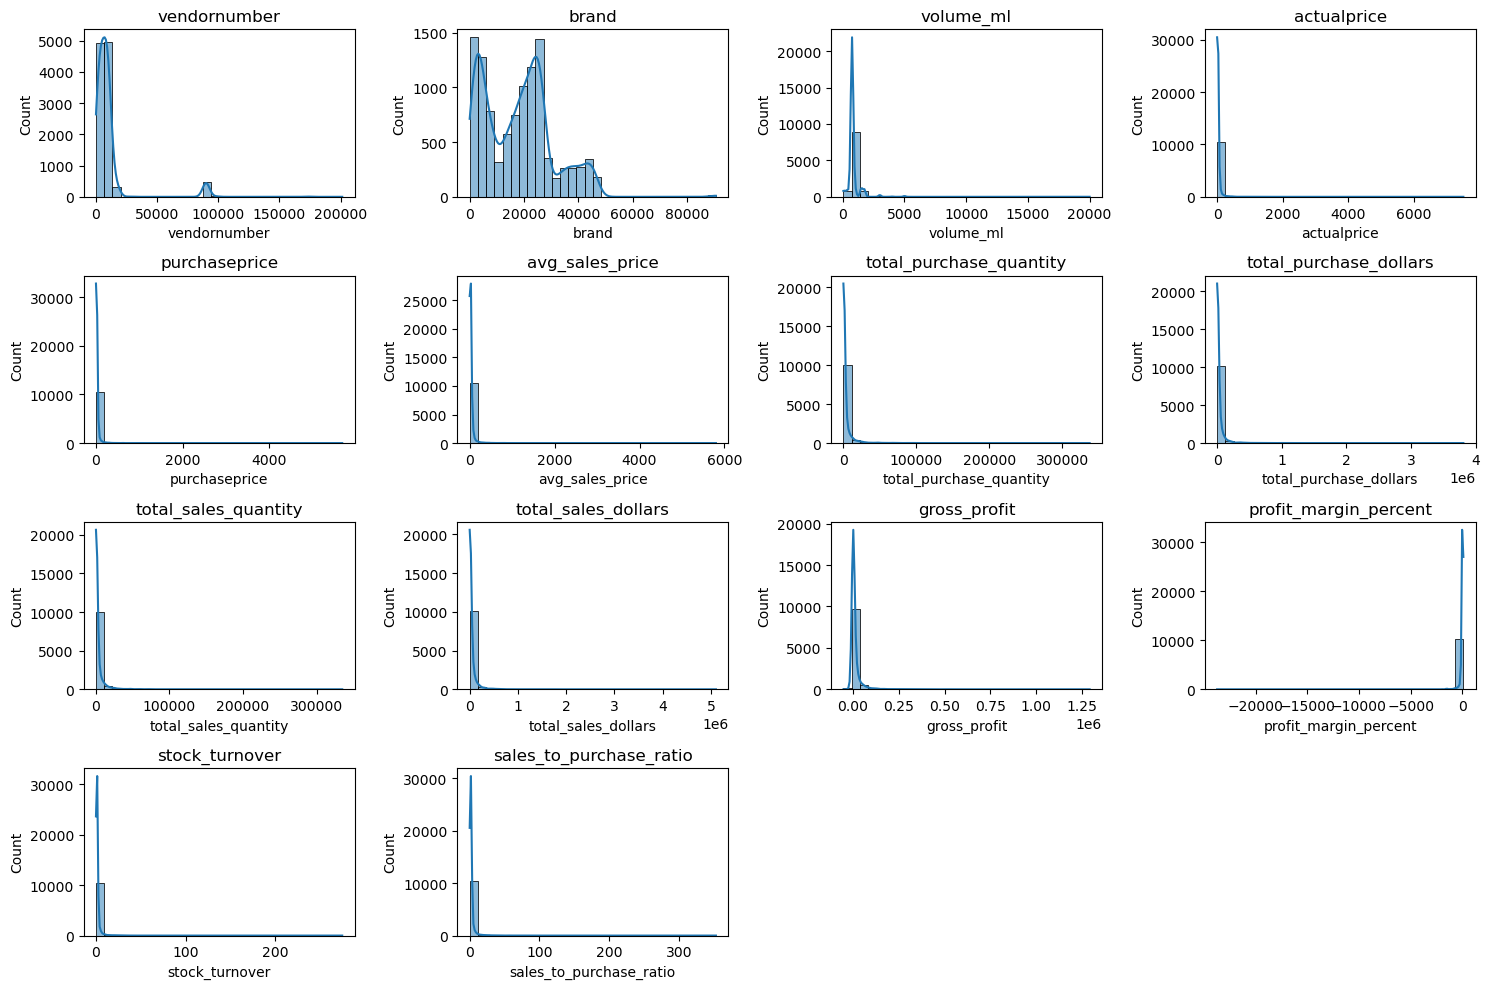

In [30]:
numerical_cols = vsps_df.select_dtypes(np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(vsps_df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

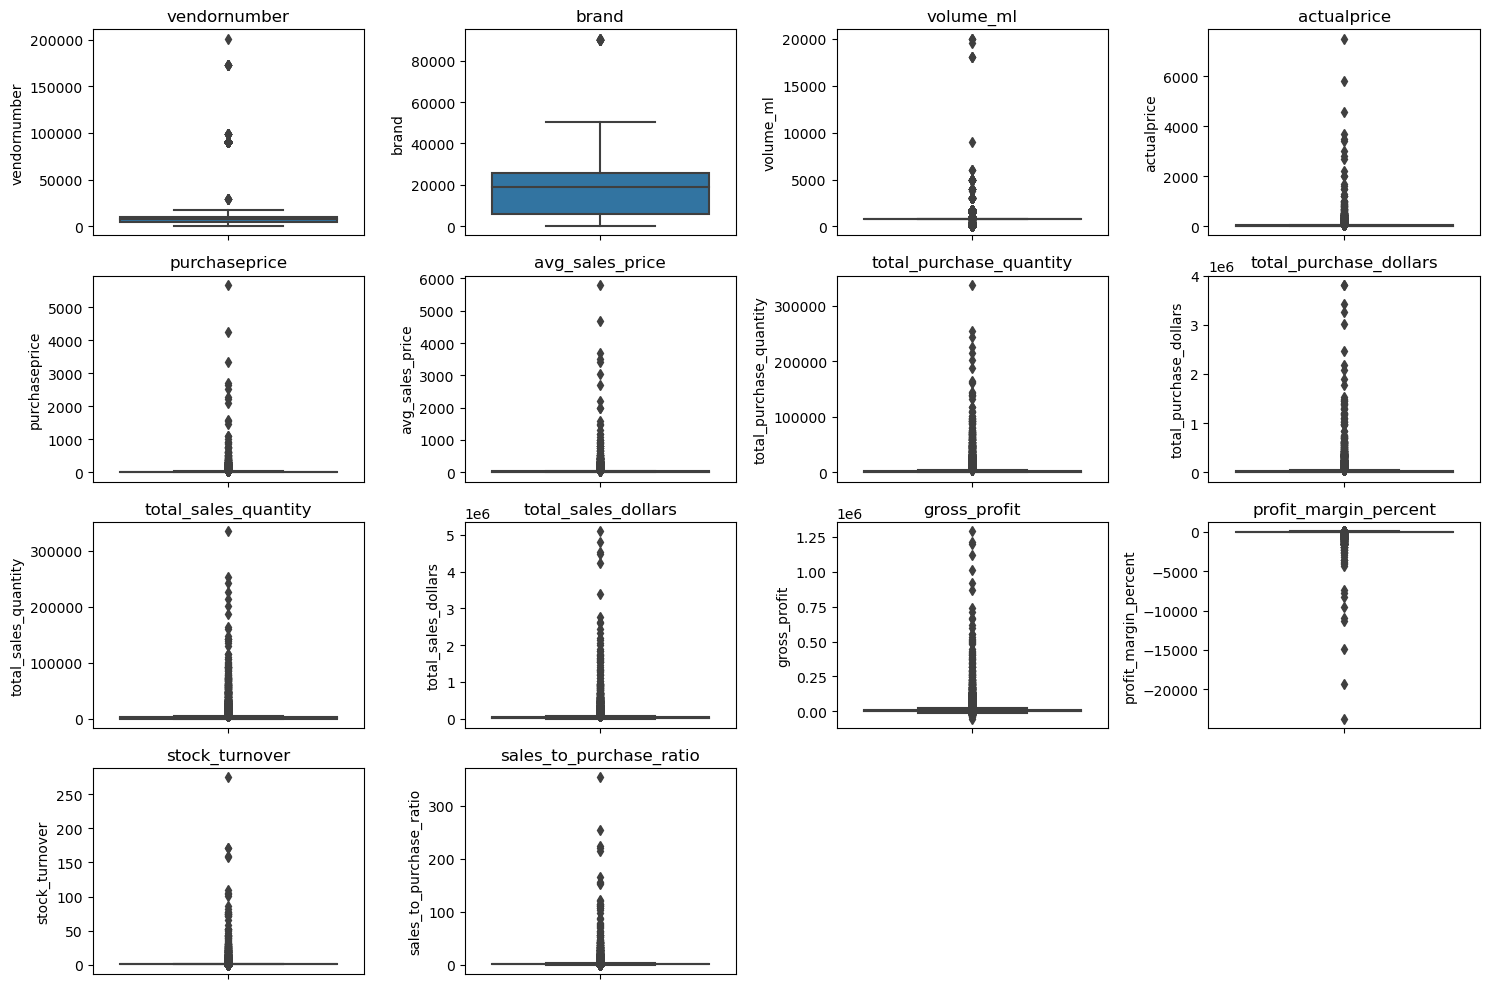

In [31]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y = vsps_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [57]:
filtered_vsps_df = pd.read_sql_query('''
                            select * 
                            from vendor_sale_purchase_summary
                            where total_sales_quantity > 0 and profit_margin_percent > 0
                                ''', con)

filtered_vsps_df.describe().T

C:\Users\mmitt\AppData\Local\Temp\ipykernel_22120\285823754.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  filtered_vsps_df = pd.read_sql_query('''


,count,mean,std,min,25%,50%,75%,max
vendornumber,8564.0,10107.074965,17635.714818,2.00,3664.0000,7153.00,9552.0000,201359.00
brand,8564.0,17614.670131,12946.130933,58.00,5375.7500,17606.00,24935.2500,90631.00
volume_ml,8564.0,864.332263,724.240079,50.00,750.0000,750.00,750.0000,20000.00
actualprice,8564.0,32.297467,112.420744,0.49,9.9900,14.99,25.9900,4559.99
purchaseprice,8564.0,21.780897,81.189624,0.36,6.6600,10.06,17.8500,3352.93
avg_sales_price,8564.0,31.822125,111.868538,0.49,10.2100,14.99,25.8475,4696.99
total_purchase_quantity,8564.0,3772.008991,12276.960631,1.00,42.0000,431.00,2666.7500,337660.00
total_purchase_dollars,8564.0,35887.253324,136722.999153,0.71,546.1875,5018.40,26610.1775,3811251.60
total_sales_quantity,8564.0,3748.983419,12125.696083,1.00,62.0000,490.50,2675.0000,334939.00
total_sales_dollars,8564.0,51542.278077,186071.489729,1.98,1355.5800,8483.78,40622.1125,5101919.51


In [58]:
filtered_vsps_df

,vendornumber,vendorname,brand,description,volume_ml,actualprice,purchaseprice,avg_sales_price,total_purchase_quantity,total_purchase_dollars,total_sales_quantity,total_sales_dollars,gross_profit,profit_margin_percent,stock_turnover,sales_to_purchase_ratio
0,1128,BROWN-FORMAN CORP,1236,Southern Comfort & Egg Nog,1750.0,18.99,13.56,24.25,8.0,108.48,87.0,2124.13,2015.65,94.89,10.88,19.58
1,12546,JIM BEAM BRANDS COMPANY,1261,Jim Beam Kentucky Fire,50.0,0.99,0.74,0.99,23774.0,17592.76,23667.0,23430.33,5837.57,24.91,1.00,1.33
2,3252,E & J GALLO WINERY,12747,Barefoot Cellars Pnt Nr,750.0,6.29,3.28,5.85,8138.0,26692.64,8220.0,47936.40,21243.76,44.32,1.01,1.80
3,12546,JIM BEAM BRANDS COMPANY,1346,Knob Creek Bourbon,750.0,29.99,22.55,30.91,25540.0,575927.00,22144.0,684455.56,108528.56,15.86,0.87,1.19
4,12546,JIM BEAM BRANDS COMPANY,1397,Jim Beam Kentucky Fire,750.0,16.99,10.76,14.94,8484.0,91287.84,8220.0,122786.30,31498.46,25.65,0.97,1.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,1650,Circa Wines,24511,Tin Barn Znfdl RRV Gilsson,750.0,21.99,14.86,21.99,12.0,178.32,12.0,263.88,85.56,32.42,1.00,1.48
8560,4425,MARTIGNETTI COMPANIES,34539,Ch Roumier-Lacoste Barsac W,375.0,24.99,17.23,24.99,3.0,51.69,3.0,74.97,23.28,31.05,1.00,1.45
8561,653,STATE WINE & SPIRITS,15677,Six Hats Chenin Blanc,750.0,11.99,7.94,11.99,12.0,95.28,12.0,143.88,48.60,33.78,1.00,1.51
8562,4425,MARTIGNETTI COMPANIES,239,Vincent Van Gogh Espresso V,750.0,27.99,21.53,27.99,6.0,129.18,6.0,167.94,38.76,23.08,1.00,1.30


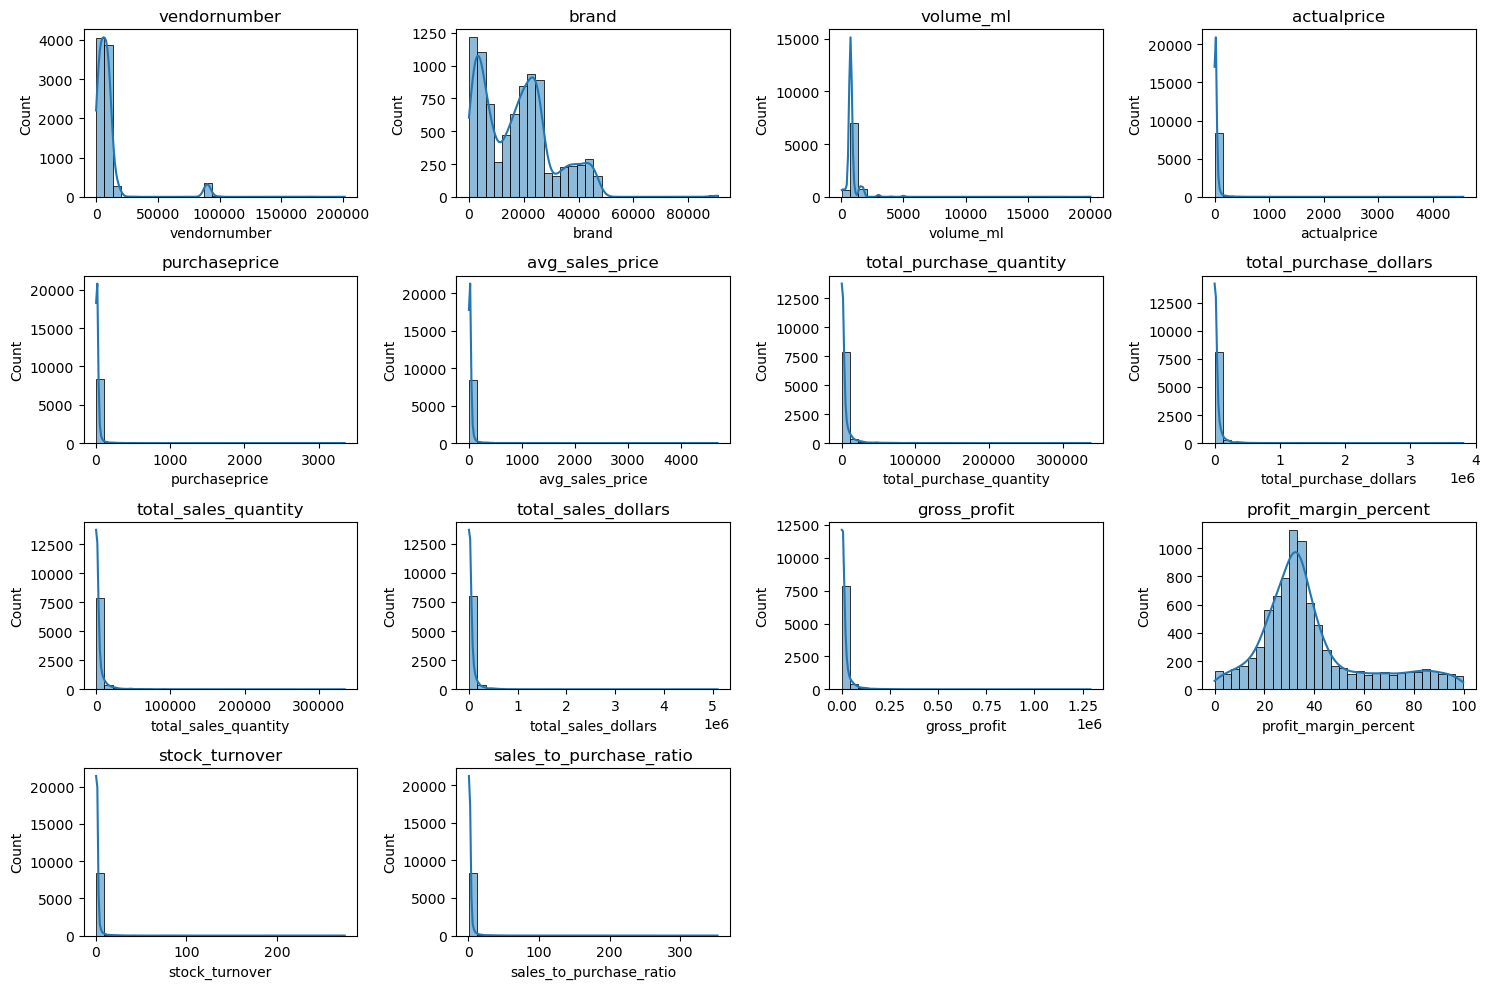

In [59]:
numerical_cols = filtered_vsps_df.select_dtypes(np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(filtered_vsps_df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

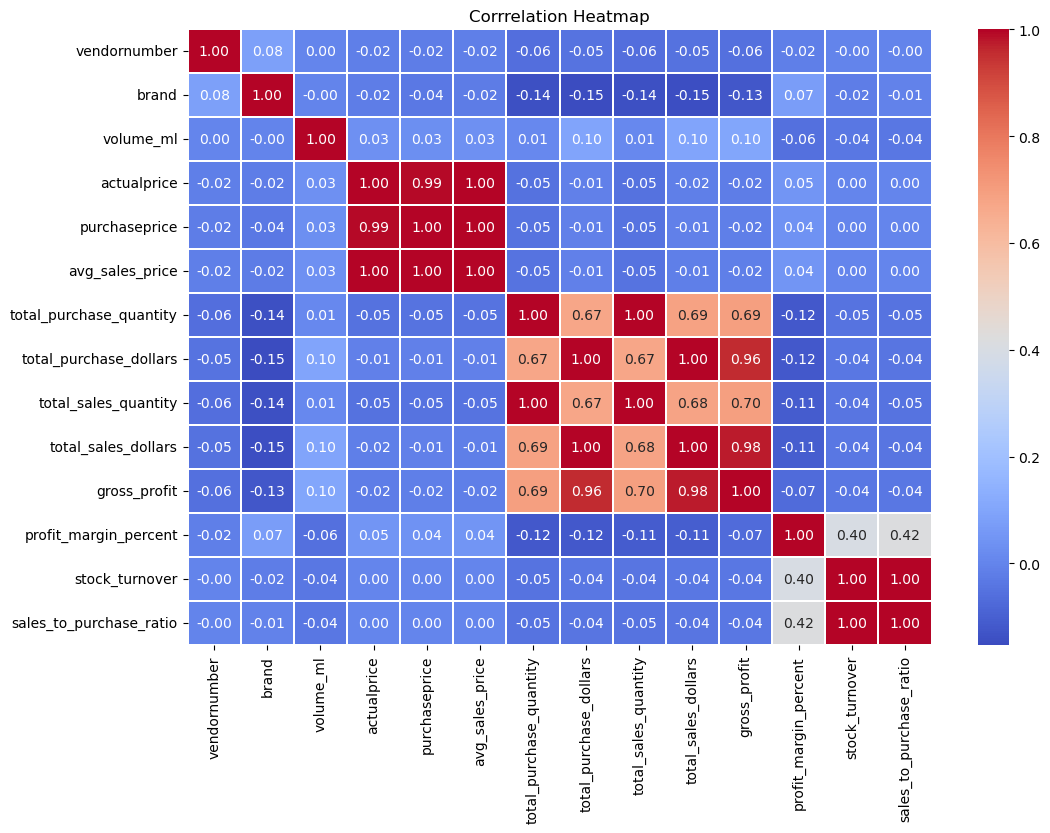

In [66]:
plt.figure(figsize=(12,8))
corr_matrix = filtered_vsps_df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.3)
plt.title('Corrrelation Heatmap')
plt.show()

# Vendor Performance Analysis

In [81]:
# Top 10 Brands that need promotional or pricing adjustment which exhibit lower sales performance but higher profit margins
# Brands lying in < 25%ile in terms of sales dollar and > 75%ile in terms of profit margins are the brands to be targeted.

brand_performance = con.execute('''
with base as
(                           
    select description, 
        sum(total_sales_dollars) as total_sales_dollars,
        avg(profit_margin_percent) as avg_profit_margin_percent
    from (select * from vendor_sale_purchase_summary where total_sales_quantity > 0 and profit_margin_percent > 0)
    group by description
    order by avg_profit_margin_percent desc, total_sales_dollars asc
), 
bucketed as 
(
    select *, 
        ntile(4) over(order by total_sales_dollars) as sales_ntile,
        ntile(4) over(order by avg_profit_margin_percent desc) as profit_ntile
    from base
)

select description as brandname, total_sales_dollars, avg_profit_margin_percent
from bucketed
where sales_ntile = 1 and profit_ntile = 1
order by avg_profit_margin_percent desc, total_sales_dollars asc
limit 10
''').fetchdf()

In [82]:
brand_performance

,brandname,total_sales_dollars,avg_profit_margin_percent
0,M Chiarlo Gavi Wh,1208.90,99.39
1,The Club Strawbry Margarita,143.28,98.97
2,Dom Janasse Terre d'Argile,1019.49,98.68
3,Cecchi Natio Organic Chianti,735.08,98.58
4,Skinnygirl Cucumber Vodka,779.48,98.56
5,Barbarossa Spiced Rum,945.14,98.22
6,Bacardi Oakheart Spiced Trav,399.60,98.13
7,Chi Chi's Chocolate Malt RTD,461.58,98.11
8,Kesselstatt Piesporter Gold,929.69,97.81
9,Penfolds B28 Shiraz/Kalimna,890.73,97.78


In [83]:
# Vendors that demonstrate highest sales performance (lies in top 5%)
top_vendors_by_sales = con.execute('''
with base as 
(
    select vendorname, sum(total_sales_dollars) as total_sales_dollar
    from (select * from vendor_sale_purchase_summary where total_sales_quantity > 0 and profit_margin_percent > 0)
    group by vendorname
), 
bucketed as 
(
    select *, 
    ntile(20) over(order by total_sales_dollar desc) as sales_ntile
    from base
)

select vendorname, total_sales_dollar
from bucketed
where sales_ntile = 1 
order by total_sales_dollar desc
''').fetchdf()

In [84]:
top_vendors_by_sales

,vendorname,total_sales_dollar
0,DIAGEO NORTH AMERICA INC,67990099.42
1,MARTIGNETTI COMPANIES,39276398.80
2,PERNOD RICARD USA,32063196.19
3,JIM BEAM BRANDS COMPANY,31423020.46
4,BACARDI USA INC,24854817.14
5,CONSTELLATION BRANDS INC,24218745.65


In [89]:
# Brands that demonstrate highest sales performance (lies in top 1%)
top_brands_by_sales = con.execute('''
with base as 
(
    select description as brandname, sum(total_sales_dollars) as total_sales_dollar
    from (select * from vendor_sale_purchase_summary where total_sales_quantity > 0 and profit_margin_percent > 0)
    group by description
), 
bucketed as 
(
    select *, 
    ntile(100) over(order by total_sales_dollar desc) as sales_ntile
    from base
)

select brandname, total_sales_dollar
from bucketed
where sales_ntile = 1 
order by total_sales_dollar desc
''').fetchdf()

In [90]:
top_brands_by_sales

,brandname,total_sales_dollar
0,Jack Daniels No 7 Black,7964746.76
1,Tito's Handmade Vodka,7399657.58
2,Grey Goose Vodka,7209608.06
3,Capt Morgan Spiced Rum,6356320.62
4,Absolut 80 Proof,6244752.03
...,...,...
73,Zhenka 80 Proof,816412.77
74,Remy Martin VSOP Cognac,815926.80
75,Apothic Winemakers Red Blend,812899.38
76,Seagrams 7 Crown,801560.19


In [91]:
# Vendors which contribute the most to total purchase contribution (top 5%)
top_vendors_by_purchse = con.execute('''
with base as 
(
    select vendorname, sum(total_purchase_dollars) as total_purchase_dollars
    from (select * from vendor_sale_purchase_summary where total_sales_quantity > 0 and profit_margin_percent > 0)
    group by vendorname
), 
bucketed as 
(
    select *, 
    ntile(20) over(order by total_purchase_dollars desc) as pur_ntile
    from base
)

select vendorname, total_purchase_dollars
from bucketed
where pur_ntile = 1 
order by total_purchase_dollars desc
''').fetchdf()

In [92]:
top_vendors_by_purchse

,vendorname,total_purchase_dollars
0,DIAGEO NORTH AMERICA INC,50097226.16
1,MARTIGNETTI COMPANIES,25464774.04
2,PERNOD RICARD USA,23851164.17
3,JIM BEAM BRANDS COMPANY,23494304.32
4,BACARDI USA INC,17432020.26
5,CONSTELLATION BRANDS INC,15273708.08


In [100]:
# Vendor purchase contribution to total purchase
vendor_purchase_contribution = con.execute('''
select vendorname, total_purchase_dollars, 
    round((total_purchase_dollars*100)/sum(total_purchase_dollars) over(), 2) as contribution_perc
from 
(
    select vendorname, 
        sum(total_purchase_dollars) as total_purchase_dollars
    from (select * from vendor_sale_purchase_summary where total_sales_quantity > 0 and profit_margin_percent > 0)
    group by vendorname
)
order by contribution_perc desc
limit 10
''').fetchdf()

In [101]:
vendor_purchase_contribution

,vendorname,total_purchase_dollars,contribution_perc
0,DIAGEO NORTH AMERICA INC,50097226.16,16.30
1,MARTIGNETTI COMPANIES,25464774.04,8.29
2,PERNOD RICARD USA,23851164.17,7.76
3,JIM BEAM BRANDS COMPANY,23494304.32,7.64
4,BACARDI USA INC,17432020.26,5.67
5,CONSTELLATION BRANDS INC,15273708.08,4.97
6,BROWN-FORMAN CORP,13238939.18,4.31
7,E & J GALLO WINERY,12068539.22,3.93
8,ULTRA BEVERAGE COMPANY LLP,11167081.61,3.63
9,M S WALKER INC,9764312.60,3.18


In [106]:
# Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings
con.execute('''
with base as 
(
select *, 
    ntile(3) over(order by total_purchase_quantity) as pur_ntile
from (select * from vendor_sale_purchase_summary where total_sales_quantity > 0 and profit_margin_percent > 0)
),
bucketed as 
(
    select *,   
        case when pur_ntile = 1 then 'Small' when pur_ntile = 2 then 'Medium' when pur_ntile = 3 then 'Large' end as ordersize
    from base
)
select ordersize, round(avg(total_purchase_dollars/total_purchase_quantity), 2) as avg_unit_price
from bucketed
group by ordersize
''').fetchdf()

,ordersize,avg_unit_price
0,Medium,15.48
1,Small,39.08
2,Large,10.78


In [110]:
# Vendors having low inventory turnover, indicating excess stock and slow moving products
con.execute('''
select vendorname, round(avg(stock_turnover), 2) as avg_stock_turnover
from 
(
    select * 
    from (select * from vendor_sale_purchase_summary where total_sales_quantity > 0 and profit_margin_percent > 0)
    where stock_turnover < 1
)
group by vendorname
order by avg_stock_turnover
limit 10
''').fetchdf()

,vendorname,avg_stock_turnover
0,ALISA CARR BEVERAGES,0.62
1,HIGHLAND WINE MERCHANTS LLC,0.71
2,PARK STREET IMPORTS LLC,0.75
3,KLIN SPIRITS LLC,0.76
4,Circa Wines,0.76
5,Dunn Wine Brokers,0.77
6,CENTEUR IMPORTS LLC,0.77
7,SMOKY QUARTZ DISTILLERY LLC,0.78
8,TAMWORTH DISTILLING,0.80
9,THE IMPORTED GRAPE LLC,0.81


In [ ]:
# Capital locked in unsold inventory per vendor and which vendor contribute to it the most
 